# Proyek Analisis Data: [bike sharing]
- **Nama:** Sandhika Hamzah
- **Email:** sanvinzah@gmail.com
- **ID Dicoding:** sandhika_hamzah_jvzn

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah total penyewaan sepeda harian?
- Bagaimana tren pertumbuhan penyewaan sepeda pada tahun 2011 dibandingkan tahun 2012?

## Import Semua Packages/Library yang Digunakan

Tahap pertama adalah mengimpor pustaka yang dibutuhkan untuk manipulasi data (Pandas, Numpy) dan visualisasi data (Matplotlib, Seaborn).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

Tahap ini meliputi pengumpulan data (Gathering), penilaian kualitas data (Assessing), dan pembersihan data (Cleaning).

### Gathering Data

Pada langkah ini, kita memuat dataset day.csv (data harian) dan hour.csv (data per jam).

In [ ]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama data harian
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset day.csv memiliki 731 baris yang merepresentasikan rangkuman harian.
- Dataset hour.csv memiliki 17.379 baris yang merepresentasikan detail per jam.
- Kedua dataset memiliki kolom yang hampir sama, namun hour.csv memiliki kolom tambahan hr (jam).

### Assessing Data

Kita akan memeriksa struktur data, tipe data setiap kolom, serta mengecek apakah terdapat missing values atau data yang duplikat.

In [ ]:
print("--- Info Day DataFrame ---")
day_df.info()

print("\n--- Pengecekan Missing Values ---")
print(day_df.isna().sum())

print("\n--- Pengecekan Duplikasi ---")
print(f"Jumlah duplikasi: {day_df.duplicated().sum()}")

# Pengecekan statistik deskriptif untuk mencari keanehan data (outliers/anomali)
print("\n--- Deskripsi Statistik ---")
print(day_df.describe())

--- Info Day DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB

--- Pengecekan Missing Values ---
instant       0
dteday        0
season        

**Insight:**
- Kolom dteday masih bertipe data object, seharusnya datetime.
- Tidak ditemukan adanya missing values atau data duplikat pada kedua dataset.
- Kolom kategorikal seperti season, yr, mnth, dan weathersit masih dalam bentuk angka (integer), yang akan menyulitkan saat pembuatan grafik jika tidak di mapping.

### Cleaning Data

Langkah pembersihan meliputi:

1.   Mengubah tipe data kolom dteday menjadi datetime.
2.   Mengubah nilai angka pada kolom kategorikal (season, mnth, weathersit) menjadi label teks agar informasi lebih akurat dan mudah dibaca (konsistensi data).

In [ ]:
# Mengubah tipe data kolom tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kategori musim (1:Spring, 2:Summer, 3:Fall, 4:Winter)
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping kondisi cuaca (1:Clear, 2:Misty, 3:Light Rain/Snow, 4:Heavy Rain)
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice'
})

# Menambahkan kolom tahun (2011 & 2012) untuk mempermudah analisis tren tahunan
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month
0,1,2011-01-01,Spring,0,1,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985,2011,1
1,2,2011-01-02,Spring,0,1,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801,2011,1
2,3,2011-01-03,Spring,0,1,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011,1
3,4,2011-01-04,Spring,0,1,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011,1
4,5,2011-01-05,Spring,0,1,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011,1


**Insight:**
- Data sudah bersih dengan tipe data tanggal yang benar.
- Penambahan label teks pada weathersit dan year akan membuat visualisasi data nantinya menjadi "self-explanatory" (mudah dipahami tanpa penjelasan tambahan).

### Menyimpan Data Bersih

Menyimpan `day_df` yang sudah dibersihkan ke `main_data.csv` agar dashboard (`dashboard.py`) memakai sumber data yang sama persis dengan hasil notebook ini.

In [ ]:
day_df.to_csv('main_data.csv', index=False)
print('main_data.csv berhasil disimpan, shape:', day_df.shape)

main_data.csv berhasil disimpan, shape: (731, 18)


## Exploratory Data Analysis (EDA)

### Explore ...

Di sini kita mengeksplorasi data untuk menjawab pertanyaan bisnis secara deskriptif sebelum divisualisasikan.

In [ ]:
# Analisis Rata-rata penyewaan per kondisi cuaca
weather_analysis = day_df.groupby('weathersit')['cnt'].mean().reset_index()
print(weather_analysis)

# Analisis Total penyewaan per tahun
yearly_analysis = day_df.groupby('year')['cnt'].sum().reset_index()
print(yearly_analysis)

            weathersit          cnt
0  Clear/Partly Cloudy  4876.786177
1      Light Snow/Rain  1803.285714
2         Misty/Cloudy  4035.862348
   year      cnt
0  2011  1243103
1  2012  2049576


**Insight:**
- Cuaca "Clear" memiliki rata-rata penyewaan tertinggi (sekitar 4.876 penyewa/hari).
- Terdapat pertumbuhan total penyewaan yang sangat signifikan dari tahun 2011 ke 2012.

## Visualization & Explanatory Analysis

Bagian ini menyajikan visualisasi data yang menerapkan prinsip integritas dan desain untuk menjawab pertanyaan bisnis secara efektif.

### Pertanyaan 1:

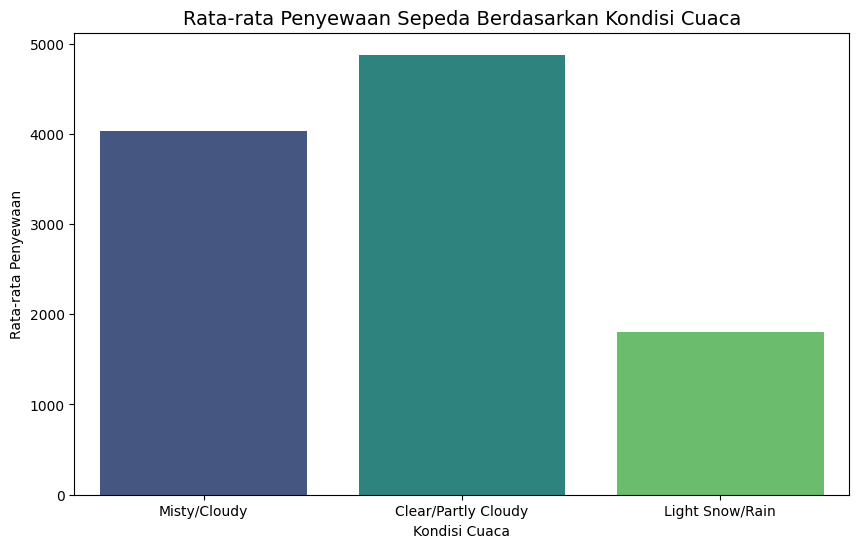

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='weathersit', y='cnt', data=day_df, hue='weathersit', palette='viridis', legend=False, errorbar=None)
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca', fontsize=14)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**

Grafik menunjukkan korelasi negatif antara buruknya cuaca dan jumlah penyewa. Pengguna jauh lebih aktif saat cuaca cerah. Penurunan drastis terjadi saat cuaca berubah menjadi "Light Rain/Snow".

### Pertanyaan 2:

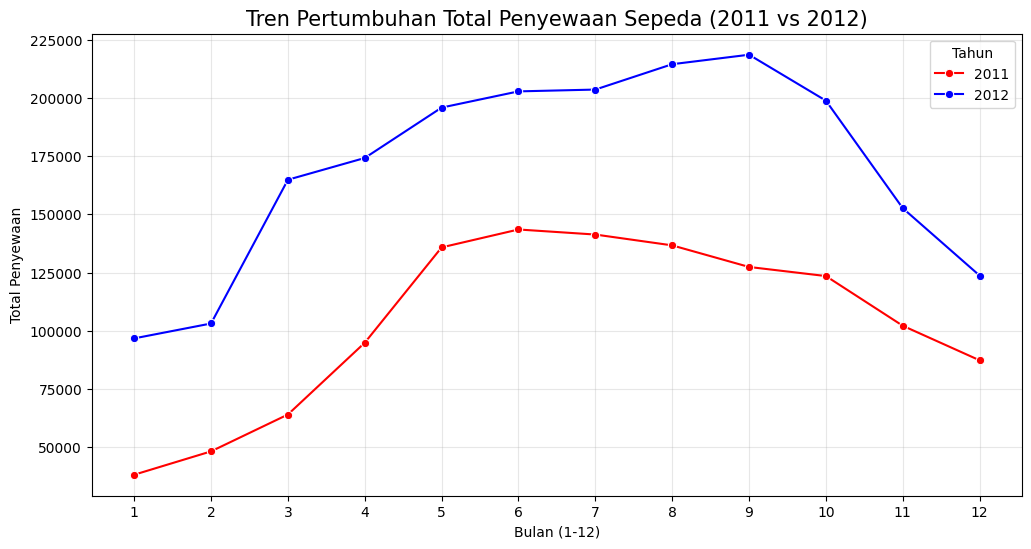

In [ ]:
# Menyiapkan data: Mengelompokkan berdasarkan tahun (yr) dan bulan (mnth)
monthly_trend = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()

# Menambahkan kolom label agar legenda di grafik jelas
monthly_trend['year_label'] = monthly_trend['yr'].map({0: '2011', 1: '2012'})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_trend,
    x='mnth',
    y='cnt',
    hue='year_label', # Ini yang membedakan warna dan membuat legenda muncul
    marker='o',
    palette=['red', 'blue'] # Merah untuk 2011, Biru untuk 2012 agar kontras
)

plt.title('Tren Pertumbuhan Total Penyewaan Sepeda (2011 vs 2012)', fontsize=15)
plt.xlabel('Bulan (1-12)')
plt.ylabel('Total Penyewaan')
plt.xticks(range(1, 13))
plt.legend(title='Tahun') # Memastikan legenda muncul
plt.grid(True, alpha=0.3)
plt.show()

**Insight:**
- Pada grafik pertama menunjukkan korelasi negatif antara buruknya cuaca dan jumlah penyewa. Pengguna jauh lebih aktif saat cuaca cerah. Penurunan drastis terjadi saat cuaca berubah menjadi "Light Rain/Snow".
- Pada grafik kedua menunjukkan bahwa penyewaan di tahun 2012 secara konsisten lebih tinggi dibandingkan 2011 di setiap bulan. Puncak penyewaan terjadi pada bulan Juni-September, yang bertepatan dengan musim panas/gugur.

## Analisis Lanjutan (Opsional)

Teknik ini mengelompokkan data berdasarkan rentang nilai tertentu (Binning). Kita akan mengelompokkan suhu (temp) menjadi tiga kategori: Cold, Moderate, dan Hot untuk melihat preferensi suhu pengguna.

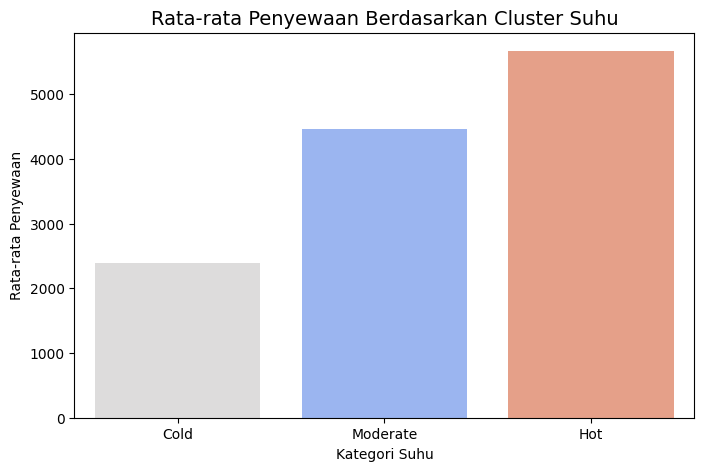

In [ ]:
# Membuat fungsi untuk clustering berdasarkan suhu
def get_temp_category(temp):
    if temp < 0.3:
        return "Cold"
    elif temp < 0.6:
        return "Moderate"
    else:
        return "Hot"

# Menerapkan fungsi ke kolom temp
day_df['temp_cluster'] = day_df['temp'].apply(get_temp_category)

# Visualisasi perbandingan rata-rata penyewaan tiap cluster
plt.figure(figsize=(8, 5))
sns.barplot(
    x='temp_cluster',
    y='cnt',
    data=day_df,
    hue='temp_cluster',
    palette='coolwarm',
    legend=False,
    errorbar=None,
    order=['Cold', 'Moderate', 'Hot']
)

plt.title('Rata-rata Penyewaan Berdasarkan Cluster Suhu', fontsize=14)
plt.xlabel('Kategori Suhu')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**

- Kelompok suhu Moderate dan Hot menunjukkan rata-rata penyewaan yang jauh lebih tinggi dibandingkan kelompok Cold.
- Ini menandakan bahwa cuaca dingin merupakan hambatan utama bagi pengguna untuk menyewa sepeda. Perusahaan dapat mempertimbangkan promosi khusus atau peningkatan fasilitas (seperti perlengkapan penghangat di titik stasiun) selama periode suhu dingin.

### Pola Penyewaan per Jam (memanfaatkan hour.csv)

Selain pola harian, `hour_df` dipakai untuk melihat jam-jam sibuk penyewaan, dibedakan antara hari kerja dan hari libur/akhir pekan.

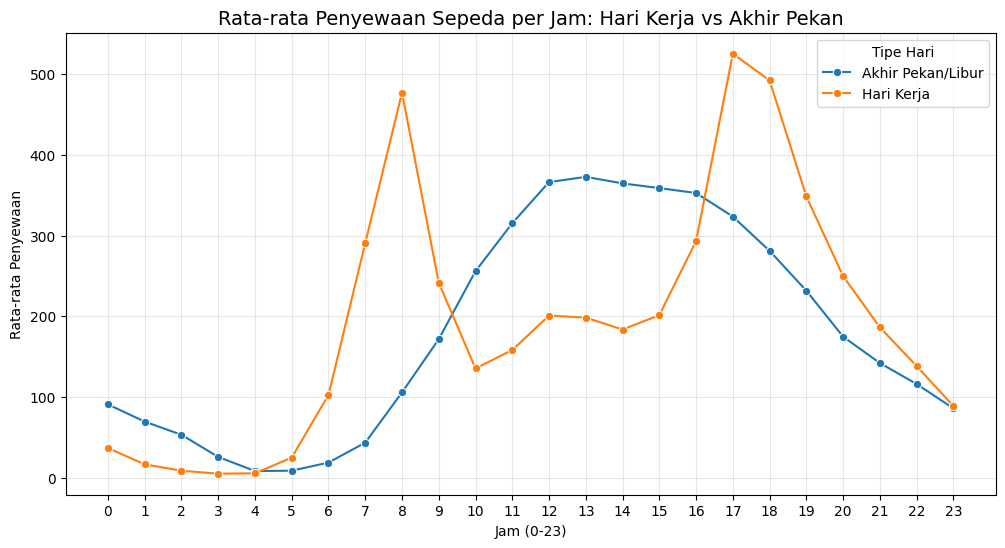

In [ ]:
hourly_pattern = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
hourly_pattern['day_type'] = hourly_pattern['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hourly_pattern,
    x='hr',
    y='cnt',
    hue='day_type',
    marker='o',
    palette=['#1f77b4', '#ff7f0e']
)
plt.title('Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan', fontsize=14)
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0, 24))
plt.legend(title='Tipe Hari')
plt.grid(True, alpha=0.3)
plt.show()

**Insight:**
- Pada hari kerja, penyewaan menunjukkan pola dua puncak (*bimodal*) yang tajam di jam 08.00 dan 17.00-18.00, konsisten dengan pola commuting berangkat-pulang kerja.
- Pada akhir pekan/hari libur, pola lebih landai dengan satu puncak lebar di siang-sore hari (sekitar jam 12.00-16.00), mengindikasikan penggunaan untuk rekreasi, bukan commuting.

## Conclusion

- Pertanyaan 1: Kondisi cuaca memiliki pengaruh yang sangat signifikan terhadap jumlah penyewaan. Cuaca cerah (Clear) adalah pendukung utama bisnis, sementara cuaca buruk seperti hujan ringan atau salju menurunkan minat pengguna secara drastis. Bisnis perlu menyesuaikan operasional atau strategi pemasaran saat musim cuaca buruk tiba.
- Pertanyaan 2:Bisnis menunjukkan pertumbuhan yang sangat positif. Total penyewaan pada tahun 2012 secara konsisten melampaui performa tahun 2011 di semua bulan. Tren musiman juga terlihat jelas, di mana permintaan memuncak pada kuartal ketiga (bulan Juni hingga September).
- analisis lanjutan:Melalui teknik manual clustering, ditemukan bahwa suhu yang nyaman (Moderate hingga Hot) adalah target pasar yang paling potensial. Suhu ekstrem dingin mengakibatkan penurunan jumlah pelanggan yang signifikan.
- Pola per jam: Hari kerja menunjukkan dua puncak penyewaan yang tajam (jam commuting pagi & sore), sementara akhir pekan menunjukkan satu puncak lebar di siang hari. Ini menegaskan bahwa bisnis melayani dua segmen berbeda: pekerja komuter dan pengguna rekreasi, yang idealnya didekati dengan strategi armada dan promosi yang berbeda pula.